# **1. Perkenalan Dataset**

Dataset ini berisi data historis pengajuan pinjaman (Loan Approval) yang mencakup informasi nasabah seperti jumlah tanggungan, pendidikan, status pekerjaan, pendapatan tahunan, nilai pinjaman, skor CIBIL, hingga nilai aset[cite: 2]. Tujuannya adalah untuk melakukan eksplorasi dan pra-pemrosesan data agar siap digunakan dalam membangun model Machine Learning yang dapat memprediksi apakah suatu pinjaman akan disetujui (`Approved`) atau ditolak (`Rejected`)[cite: 2].

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [14]:
# Memuat dataset mentah
df = pd.read_csv('loan_dataset_raw/loan_approval_dataset.csv')

# Melihat 5 baris pertama
display(df.head())

# Cek informasi data
print(df.info())

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


<class 'pandas.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   loan_id                    4269 non-null   int64
 1    no_of_dependents          4269 non-null   int64
 2    education                 4269 non-null   str  
 3    self_employed             4269 non-null   str  
 4    income_annum              4269 non-null   int64
 5    loan_amount               4269 non-null   int64
 6    loan_term                 4269 non-null   int64
 7    cibil_score               4269 non-null   int64
 8    residential_assets_value  4269 non-null   int64
 9    commercial_assets_value   4269 non-null   int64
 10   luxury_assets_value       4269 non-null   int64
 11   bank_asset_value          4269 non-null   int64
 12   loan_status               4269 non-null   str  
dtypes: int64(10), str(3)
memory usage: 531.6 KB
None


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

Jumlah Missing Values per Kolom:
 loan_id                     0
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64


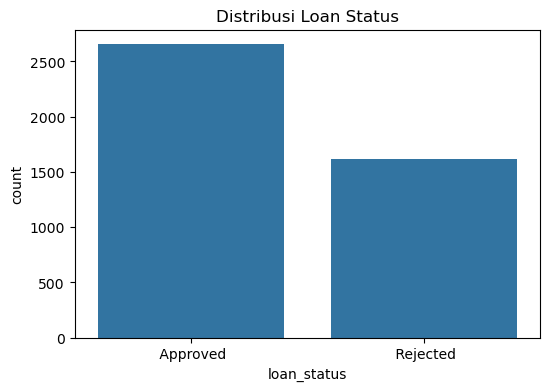

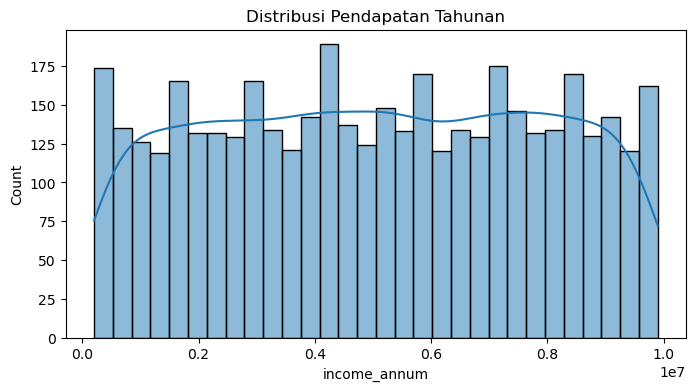

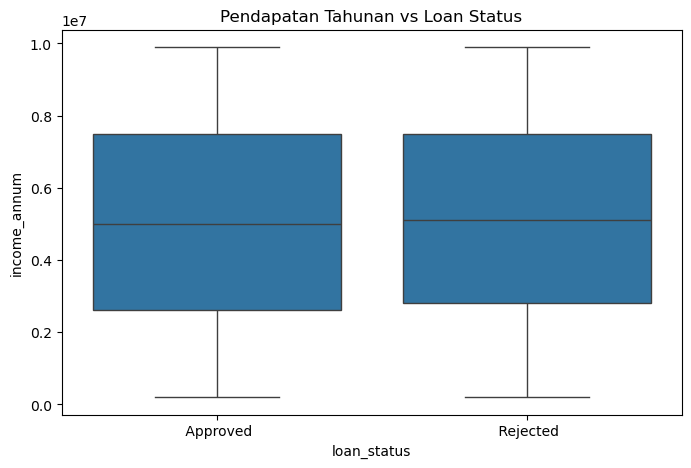

In [15]:
# 0. Bersihkan spasi tersembunyi pada nama kolom agar terbaca oleh Seaborn
df.columns = df.columns.str.strip()

# Mengecek missing values
print("Jumlah Missing Values per Kolom:\n", df.isnull().sum())

# 1. Univariate: Distribusi Target (loan_status)
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='loan_status')
plt.title('Distribusi Loan Status')
plt.show()

# 2. Univariate: Distribusi Pendapatan
plt.figure(figsize=(8,4))
sns.histplot(df['income_annum'], kde=True, bins=30)
plt.title('Distribusi Pendapatan Tahunan')
plt.show()

# 3. Bivariate: Hubungan Pendapatan dan Status Pinjaman
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='loan_status', y='income_annum')
plt.title('Pendapatan Tahunan vs Loan Status')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [16]:
# 1. Menghapus kolom 'loan_id' karena tidak punya pola untuk machine learning
df = df.drop(columns=['loan_id'])

# 2. Menghapus spasi berlebih pada isi data bertipe teks (kategorikal)
cat_cols = ['education', 'self_employed', 'loan_status']
for col in cat_cols:
    df[col] = df[col].str.strip()

# 3. Feature Engineering (Membuat fitur baru untuk mempermudah model)
df['total_assets_value'] = df['residential_assets_value'] + df['commercial_assets_value'] + df['luxury_assets_value'] + df['bank_asset_value']

# 4. Menghapus kolom aset individu agar tidak terjadi redundansi data
df = df.drop(columns=['residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value'])

# 5. Mengubah Target 'loan_status' (Approved/Rejected) menjadi angka biner (1/0)
df['loan_status'] = df['loan_status'].map({'Approved': 1, 'Rejected': 0})

# 6. One-Hot Encoding untuk kolom teks lainnya
kategorikal_kolom = ['education', 'self_employed']
df_cleaned = pd.get_dummies(df, columns=kategorikal_kolom, drop_first=True)

# 7. MENYIMPAN DATA BERSIH (Dataset Output)
df_cleaned.to_csv('loanDataset_preprocessing.csv', index=False)
print("\nSukses! Data bersih telah disimpan sebagai 'loanDataset_preprocessing.csv'")

# 8. Tampilkan data final
display(df_cleaned.head())


Sukses! Data bersih telah disimpan sebagai 'loanDataset_preprocessing.csv'


,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,loan_status,total_assets_value,education_Not Graduate,self_employed_Yes
0,2,9600000,29900000,12,778,1,50700000,False,False
1,0,4100000,12200000,8,417,0,17000000,True,True
2,3,9100000,29700000,20,506,0,57700000,False,False
3,3,8200000,30700000,8,467,0,52700000,False,False
4,5,9800000,24200000,20,382,0,55000000,True,True
